In [2]:
import sys
from pathlib import Path

scripts_path = Path("../scripts").resolve()
sys.path.append(str(scripts_path))

import rq5_function_lib as fl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import seaborn as sns
import numpy as np
import polars as pl
import plotly.express as px
import plotly.graph_objects as go

## RQ5: E10 - Diesel Price comparison and frquency of anomalies (Diesel price = E10 price//Diesel price > E10 price)

In [3]:
# Paths
# anomalies_path_pc = Path(r"C:\Users\Marvin\Dokumente\Bildung\Uni\dsprojekt\tankerkoenig-data\anomalies")
# parquet_base_pc = Path(r"C:\Users\Marvin\Dokumente\Bildung\Uni\dsprojekt\tankerkoenig-data\prices_parquet")
anomalies_path = Path(r"D:\Tankdaten\anomalies")
parquet_base = Path(r"D:\Tankdaten\prices_parquet")
# Load files
anomaly_files = sorted(anomalies_path.glob("*_all_anomalies.parquet"))

print(f"Gefundene Anomalie-Dateien: {len(anomaly_files)}")
for f in anomaly_files:
    print(f"  - {f.name}")


Gefundene Anomalie-Dateien: 13
  - 2014_all_anomalies.parquet
  - 2015_all_anomalies.parquet
  - 2016_all_anomalies.parquet
  - 2017_all_anomalies.parquet
  - 2018_all_anomalies.parquet
  - 2019_all_anomalies.parquet
  - 2020_all_anomalies.parquet
  - 2021_all_anomalies.parquet
  - 2022_all_anomalies.parquet
  - 2023_all_anomalies.parquet
  - 2024_all_anomalies.parquet
  - 2025_all_anomalies.parquet
  - 2026_all_anomalies.parquet


In [4]:
# Define the range of years you want to analyze
start_year = 2020
end_year = 2027

# Combine anomalies from how many years you want to see
dfs = []
for year in range(start_year, end_year): 
    year_file = anomalies_path / f"{year}_all_anomalies.parquet"
    if year_file.exists():
        try:
            df = pl.read_parquet(year_file)
            # Convert date to datetime (only date part, ignore time and timezone)
            df = df.with_columns(
                pl.col("date")
                .str.slice(0, 10)  # Only take YYYY-MM-DD
                .str.to_date()
                .alias("date_parsed")
            )
            dfs.append(df)
            print(f"{year} loaded ({df.height:,} anomalies)")
        except Exception as e:
            print(f"X {year} error: {e}")


combined = pl.concat(dfs)
combined = combined.with_columns(
    year=pl.col("date_parsed").dt.year(),
    month=pl.col("date_parsed").dt.month(),
    week=pl.col("date_parsed").dt.week()
)
print(f"\nTotal Anomalies: {combined.height:,} from {start_year}-{end_year-1}")


2020 loaded (4,137,648 anomalies)
2021 loaded (5,102,122 anomalies)
2022 loaded (98,031,569 anomalies)
2023 loaded (39,088,995 anomalies)
2024 loaded (14,994,480 anomalies)
2025 loaded (14,982,686 anomalies)
2026 loaded (5,770,526 anomalies)

Total Anomalies: 182,108,026 from 2020-2026


## E10-Diesel Anomalies per Month (for yearss loaded)

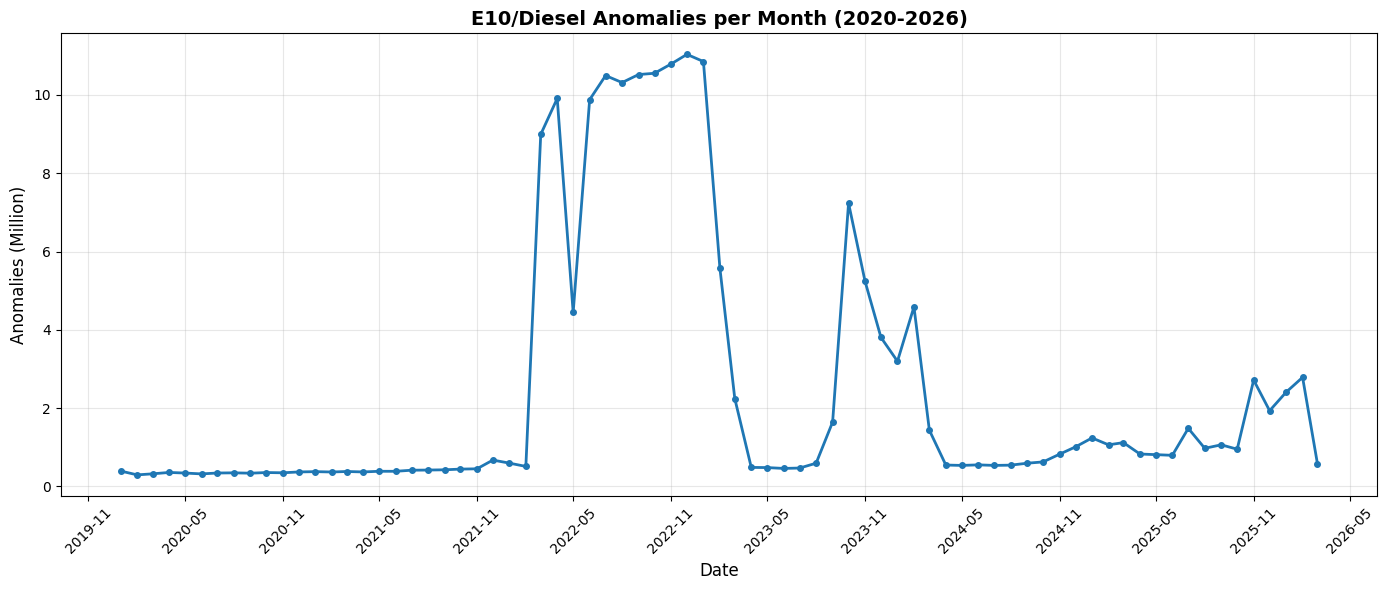

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

anomalies_per_month = combined.group_by(["year", "month"]).agg(pl.len().alias("count")).sort(["year", "month"])
anomalies_df = anomalies_per_month.to_pandas()
anomalies_df["date"] = pd.to_datetime(anomalies_df[["year", "month"]].assign(day=1))

ax.plot(anomalies_df["date"], anomalies_df["count"]/1_000_000, marker="o", linewidth=2, markersize=4)
ax.set_title(f"E10/Diesel Anomalies per Month ({start_year}-{end_year-1})", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Anomalies (Million)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Total Anomalies per year

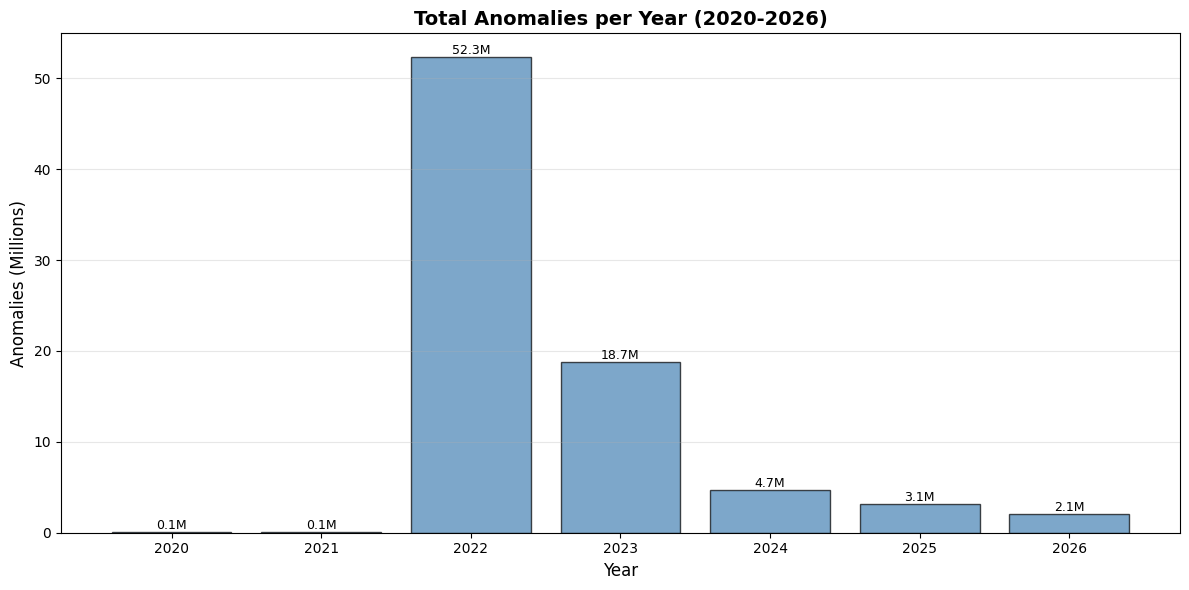

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

anomalies_per_year = combined.group_by("year").agg(pl.len().alias("count")).sort("year")
year_data = anomalies_per_year.to_pandas()

bars = ax.bar(year_data["year"], year_data["count"]/1_000_000, color="steelblue", alpha=0.7, edgecolor="black")
ax.set_title(f"Total Anomalies per Year ({start_year}-{end_year-1})", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Anomalies (Millions)", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.1f}M",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## Distribution of Price anomalies by hour of day for any year

In [ ]:
parquet_base = Path(r"D:\Tankdaten\prices_parquet")

year = 2024

lf = pl.scan_parquet(str(parquet_base / str(year) / "*.parquet"))

lf = lf.with_columns([
    pl.col("date")
        .str.replace(r"\+\d+$", "")   # timezone fix chatgpt
        .str.to_datetime("%Y-%m-%d %H:%M:%S")
        .dt.hour()
        .alias("hour"),

    (
        pl.col("diesel").is_not_null() &
        pl.col("e10").is_not_null() &
        (pl.col("diesel") >= pl.col("e10"))
    ).alias("anomaly")
])

hourly = (
    lf.group_by("hour")
    .agg([
        pl.len().alias("updates"),
        pl.col("anomaly").sum().alias("anomalies")
    ])
    .with_columns(
        (pl.col("anomalies") / pl.col("updates")).alias("anomaly_rate")
    )
    .sort("hour")
    .collect()
)

fig = px.bar(
    hourly.to_pandas(),
    x="hour",
    y="anomaly_rate",
    title=f"Anomaly Rate by Hour of Day ({year})",
    labels={"hour": "Hour of Day", "anomaly_rate": "Anomaly Rate"}
)

fig.show()

In [7]:
import importlib
import rq5_function_lib

importlib.reload(rq5_function_lib)

<module 'rq5_function_lib' from 'C:\\Users\\marvh\\Documents\\Uni\\dsprojekt\\Data-Science-Projekt\\scripts\\rq5_function_lib.py'>

### Top 100 Gas Stations with highest anomalie rate (= anomalies/price updates) between 2020 and 2026

In [ ]:
stations_csv = Path(r"C:/Users/Marvin/Dokumente/Bildung/Uni/dsprojekt/tankerkoenig-data/stations/stations.csv")
stations_parquet = Path("stations.parquet")

stations = fl.load_stations(stations_csv, stations_parquet)

# counts
anomalies = fl.anomalies_per_station(combined)

updates = fl.total_updates(parquet_base, start_year, end_year)

station_stats = fl.anomaly_rate(anomalies, updates)

station_stats = station_stats.filter(
    pl.col("updates") > 50000
)
gas_stations = 100
map_df = fl.prepare_station_map(station_stats, stations, top_n=gas_stations)

station_data = map_df.to_pandas()


fig = go.Figure()

station_data = map_df.to_pandas()

fig = px.scatter_map(
    station_data,
    lat="latitude",
    lon="longitude",
    size="anomaly_rate",
    color="anomaly_rate",
    hover_name="name",
    hover_data={
        "anomalies": True,
        "updates": True,
        "anomaly_rate": ":.3f"
    },
    size_max=18,
    zoom=6,
    height=600,
    title=f"Top {gas_stations} Gas Stations by Anomaly Rate ({start_year}-{end_year-1})",
    color_continuous_scale="Turbo"
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

display(
    map_df
    .select(["name", "anomalies", "updates", "anomaly_rate"])
    .sort("anomaly_rate", descending=True)
)

name,anomalies,updates,anomaly_rate
str,u32,i64,f64
"""ELAN LEIPZIG""",12531,54240,0.231029
"""TOTAL LEIPZIG""",12296,53671,0.2291
"""TOTAL LEIPZIG""",12941,57400,0.225453
"""TOTAL LEIPZIG""",12997,59231,0.219429
"""TOTAL LEIPZIG""",11477,52990,0.216588
…,…,…,…
"""Unknown """,9274,53398,0.173677
"""TOTAL SONNEBERG""",10169,58686,0.173278
"""LD Tankstelle Westheim Rosenga…",9453,54640,0.173005


## Median anomaly duration by year

In [18]:
path = Path("D:/Tankdaten/anomalies/anomaly_durations")
df_durations = (
    pl.scan_parquet(str(path / "real_anomaly_durations_*.parquet"))
    .with_columns(
        pl.col("start").dt.year().alias("year")
    ) \
    .collect()
)

year_stats = (
    df.group_by("year")
    .agg(pl.col("duration_min").median().alias("median_duration"))
    .sort("year")
)

fig = px.line(
    year_stats.to_pandas(),
    x="year",
    y="median_duration",
    markers=True,
    title="Median Anomaly Duration by Year"
)
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Median Duration (minutes)"
)
fig.show()

# Anomaly Distribution by year

In [20]:
duration_stats = (
    df_durations
    .group_by("year")
    .agg([
        pl.col("duration_min").quantile(0.25).alias("q025"),
        pl.col("duration_min").median().alias("median"),
        pl.col("duration_min").quantile(0.75).alias("q075"),
        pl.col("duration_min").min().alias("min"),
        pl.col("duration_min").max().alias("max"),
    ])
    .sort("year")
)

fig = go.Figure()

for row in duration_stats.iter_rows(named=True):
    fig.add_trace(go.Box(
        x=[row["year"]],
        q1=[row["q025"]],
        median=[row["median"]],
        q3=[row["q075"]],
        lowerfence=[row["min"]],
        upperfence=[row["max"]],
        name=str(row["year"]),
        boxpoints=False
    ))

fig.update_layout(
    title="Anomaly Duration Distribution by Year",
    yaxis_type="log",
    yaxis_title="Duration (minutes)"
)

fig.show()

### e.g. 2022: 50% of anomalies are shorter and 50% are longer than 864 minutes, 25% are shorter than 114 minutes and 75% are shorter than 8159 minutes and 50% of anomalies lasts between 114 and 8159 minutes